Dataset Preview:
  Store ID SKU ID  Total Visits  Transactions   Revenue
0  Store_1  SKU_1           606           573  74688.67
1  Store_1  SKU_2           695            27   1390.60
2  Store_1  SKU_3           389           285  50679.63
3  Store_1  SKU_4           689           505  16764.34
4  Store_1  SKU_5           522           230  41928.40
Updated dataset saved to 'updated_dataset_with_rates.xlsx'.


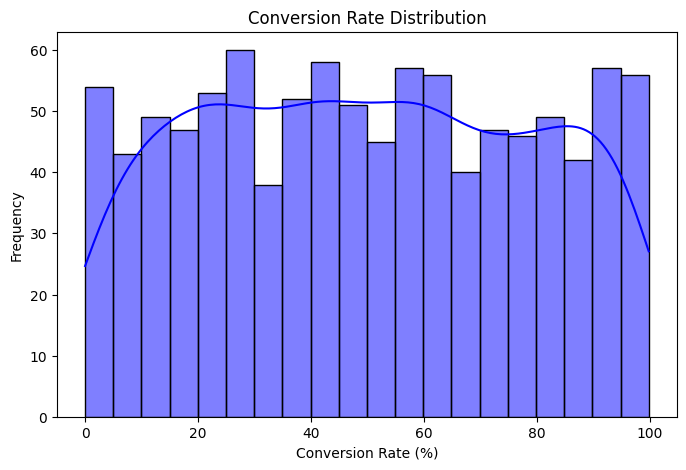

C:\Users\Sk190\AppData\Local\Temp\ipykernel_19644\2085177459.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_stores.index, y=top_5_stores['Store_Rate'], palette="viridis")


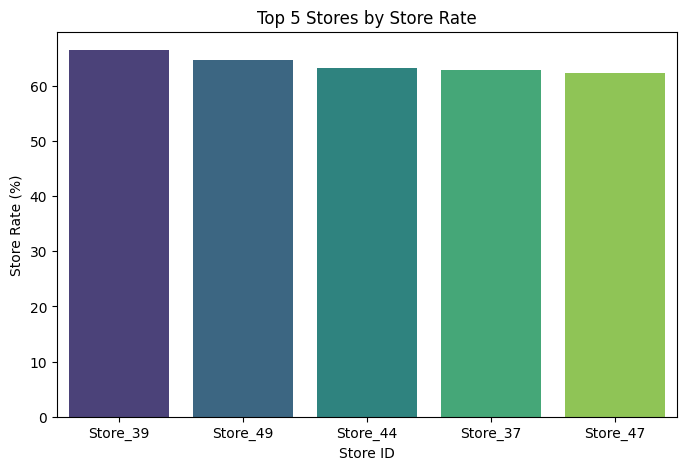

C:\Users\Sk190\AppData\Local\Temp\ipykernel_19644\2085177459.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_skus.index, y=top_5_skus['Product_Rate'], palette="viridis")


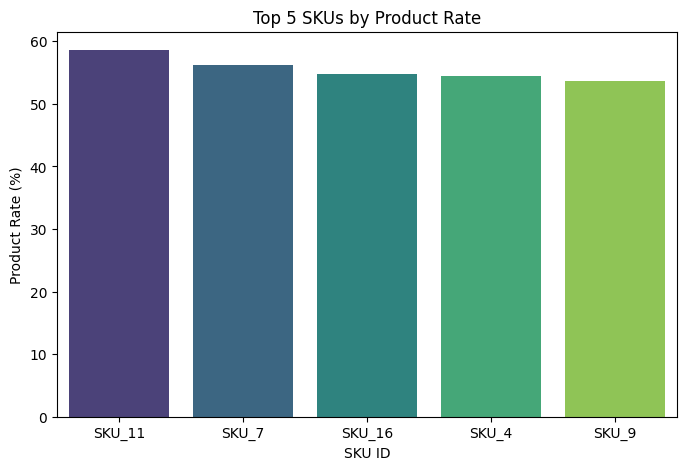

Updated Excel file with visualizations saved to 'updated_dataset_with_rates.xlsx'.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from openpyxl import load_workbook
from openpyxl.drawing.image import Image

# Load the dataset
file_path = 'C:\\Users\\Sk190\\Downloads\\store_sku_ba_dataset.csv'  # Replace with the actual path to your dataset
data = pd.read_csv(file_path)

# Preview the dataset
print("Dataset Preview:")
print(data.head())

# Calculate Conversion Rate (row-level)
data['Conversion_Rate'] = (data['Transactions'] / data['Total Visits']) * 100  # Conversion rate in percentage

# Calculate Product (SKU) Rate
sku_summary = data.groupby('SKU ID').agg(
    Total_Visits=('Total Visits', 'sum'),
    Total_Transactions=('Transactions', 'sum')
)
sku_summary['Product_Rate'] = (sku_summary['Total_Transactions'] / sku_summary['Total_Visits']) * 100

# Map Product Rate back to the original dataset
data = data.merge(sku_summary[['Product_Rate']], on='SKU ID', how='left')

# Calculate Store Rate
store_summary = data.groupby('Store ID').agg(
    Total_Visits=('Total Visits', 'sum'),
    Total_Transactions=('Transactions', 'sum')
)
store_summary['Store_Rate'] = (store_summary['Total_Transactions'] / store_summary['Total_Visits']) * 100

# Map Store Rate back to the original dataset
data = data.merge(store_summary[['Store_Rate']], on='Store ID', how='left')

# Save the updated dataset to a new Excel file
output_file = 'updated_dataset_with_rates.xlsx'
data.to_excel(output_file, index=False)
print(f"Updated dataset saved to '{output_file}'.")

# Visualizations
# 1. Conversion Rate Distribution
plt.figure(figsize=(8, 5))
sns.histplot(data['Conversion_Rate'], bins=20, kde=True, color='blue')
plt.title("Conversion Rate Distribution")
plt.xlabel("Conversion Rate (%)")
plt.ylabel("Frequency")
plt.savefig("conversion_rate_distribution.png")
plt.show()

# 2. Top 5 Stores by Store Rate
top_5_stores = store_summary.sort_values(by='Store_Rate', ascending=False).head(5)
plt.figure(figsize=(8, 5))
sns.barplot(x=top_5_stores.index, y=top_5_stores['Store_Rate'], palette="viridis")
plt.title("Top 5 Stores by Store Rate")
plt.xlabel("Store ID")
plt.ylabel("Store Rate (%)")
plt.savefig("top_5_stores.png")
plt.show()

# 3. Top 5 SKUs by Product Rate
top_5_skus = sku_summary.sort_values(by='Product_Rate', ascending=False).head(5)
plt.figure(figsize=(8, 5))
sns.barplot(x=top_5_skus.index, y=top_5_skus['Product_Rate'], palette="viridis")
plt.title("Top 5 SKUs by Product Rate")
plt.xlabel("SKU ID")
plt.ylabel("Product Rate (%)")
plt.savefig("top_5_skus.png")
plt.show()

# Add visualizations to the Excel file
wb = load_workbook(output_file)
ws = wb.active

# Insert images into the Excel file
img1 = Image("conversion_rate_distribution.png")
img2 = Image("top_5_stores.png")
img3 = Image("top_5_skus.png")

ws.add_image(img1, "J2")  # Adjust cell position as needed
ws.add_image(img2, "J22")  # Adjust cell position as needed
ws.add_image(img3, "J42")  # Adjust cell position as needed

# Save the updated Excel file with images
wb.save(output_file)
print(f"Updated Excel file with visualizations saved to '{output_file}'.")